In [89]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [31]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "./market-analysis-project-91130-9f9a036682b6.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [33]:

sql = f"""
select * from tmp1.stckln_amz_mattress_ms_trend 
where yr_month > '25-01'
"""

df = bqclient.query(sql).to_dataframe()

In [34]:
df

,spring_type,final_category,bsr_ctgry_label,Brand_raw,Brand_adj,RetailerSku,Title,imageUrl,WeekEnding,RetailSales,...,BRAND_OTHERS_6MONTH,RetailSales_TTL,RetailSales_TTL_6month,Brand_ord,Brand_ord_6month,RetailSales_MS_TTL,brand_family3,brand_family_order,brand_family4,brand_family4_order
0,None,Others,07. Mattress Pads & Toppers,MARSAIL,MARSAIL,B0CG5ZYY2Y,1,None,2025-02-15,239.97,...,OTHERS,1.988748e+10,2.371702e+10,99999999,99999999,2.808612e+08,OTHERS,13,OTHERS,11
1,None,Others,07. Mattress Pads & Toppers,MARSAIL,MARSAIL,B0CG5ZYY2Y,1,None,2025-02-08,239.97,...,OTHERS,1.988748e+10,2.371702e+10,99999999,99999999,2.808612e+08,OTHERS,13,OTHERS,11
2,None,Others,07. Mattress Pads & Toppers,MARSAIL,MARSAIL,B0CG5ZYY2Y,1,None,2025-02-22,79.99,...,OTHERS,1.988748e+10,2.371702e+10,99999999,99999999,2.808612e+08,OTHERS,13,OTHERS,11
3,None,Spring Mattress,03. Mattress & Box Spring Sets,NUTAN,NUTAN,B0F8NSC59G,"10-inch Pillow top Medium Firm, innerspring Ma...",None,2025-06-21,357.56,...,NUTAN,1.988748e+10,2.459910e+06,99999999,123,9.231504e+05,OTHERS,13,OTHERS,11
4,None,Foam Mattress,07. Mattress Pads & Toppers,ROXZO,ROXZO,B0CK2TNTYS,3 inch Memory Foam Trifold Cot Size Folding Ma...,None,2025-06-07,1091.88,...,OTHERS,1.988748e+10,2.371702e+10,99999999,99999999,2.808612e+08,OTHERS,13,OTHERS,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96987,None,Hybrid Mattress,01. Mattresses,WOOD-IT,WOOD-IT,B0C816F46Q,"wOod-it Twin Mattress, 8 Inch Twin Mattress wi...",None,2025-06-14,105.99,...,OTHERS,1.988748e+10,2.371702e+10,99999999,99999999,8.679356e+08,OTHERS,13,OTHERS,11
96988,None,Hybrid Mattress,01. Mattresses,WOOD-IT,WOOD-IT,B0C816F46Q,"wOod-it Twin Mattress, 8 Inch Twin Mattress wi...",None,2025-05-24,105.99,...,OTHERS,1.988748e+10,2.371702e+10,99999999,99999999,8.679356e+08,OTHERS,13,OTHERS,11
96989,None,Hybrid Mattress,01. Mattresses,WOOD-IT,WOOD-IT,B0C816F46Q,"wOod-it Twin Mattress, 8 Inch Twin Mattress wi...",None,2025-06-07,105.99,...,OTHERS,1.988748e+10,2.371702e+10,99999999,99999999,8.679356e+08,OTHERS,13,OTHERS,11
96990,Bonnell,Foam Mattress,01. Mattresses,WOOD-IT,WOOD-IT,B0BVZK1S5F,"wOod-it Twin Mattress, 8 inch Twin Mattresses ...",None,2025-05-24,129.99,...,OTHERS,1.988748e+10,2.371702e+10,99999999,99999999,8.679356e+08,OTHERS,13,OTHERS,11


In [37]:
df['RetailerSku'].nunique()

10373

In [39]:
df.to_csv("data_0714.csv", index=False)

### 데이터 탐색

### 2025년 Amazon Mattress 카테고리 Data 분석

In [41]:
df = pd.read_csv('data_0714.csv')

In [111]:
print(df)

      spring_type   final_category                 bsr_ctgry_label  \
0             NaN           Others     07. Mattress Pads & Toppers   
1             NaN           Others     07. Mattress Pads & Toppers   
2             NaN           Others     07. Mattress Pads & Toppers   
3             NaN  Spring Mattress  03. Mattress & Box Spring Sets   
4             NaN    Foam Mattress     07. Mattress Pads & Toppers   
...           ...              ...                             ...   
96987         NaN  Hybrid Mattress                  01. Mattresses   
96988         NaN  Hybrid Mattress                  01. Mattresses   
96989         NaN  Hybrid Mattress                  01. Mattresses   
96990     Bonnell    Foam Mattress                  01. Mattresses   
96991         NaN           Others                  01. Mattresses   

        Brand_raw   Brand_adj RetailerSku  \
0         MARSAIL     MARSAIL  B0CG5ZYY2Y   
1         MARSAIL     MARSAIL  B0CG5ZYY2Y   
2         MARSAIL     MA

### 1. 기초 통계

#### 1.1 몇 개의 ASIN이 있나요?

In [95]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

In [60]:
df['RetailerSku'].nunique() 

10373

#### 1.2 SKU별 매출합 구하기

In [78]:
sku_sales = df.groupby('RetailerSku')['RetailSales'].sum().sort_values(ascending=False).reset_index()

In [82]:
sku_sales['CumulSales'] = sku_sales['RetailSales'].cumsum()

In [84]:
sku_sales

,RetailerSku,RetailSales,CumulSales
0,B0BCYPWNWT,9339899.52,9.339900e+06
1,B0CKYZ3B83,9180964.57,1.852086e+07
2,B0CKZ1CK1H,7292219.03,2.581308e+07
3,B0DCXFXGBM,5885132.00,3.169822e+07
4,B0D7QW9612,5741208.39,3.743942e+07
...,...,...,...
10368,B0CDHBT64L,16.49,6.888918e+08
10369,B0DX7LG9M6,5.00,6.888918e+08
10370,B0DX7K6XQ2,3.00,6.888918e+08
10371,B0DX7JD1JS,2.00,6.888918e+08


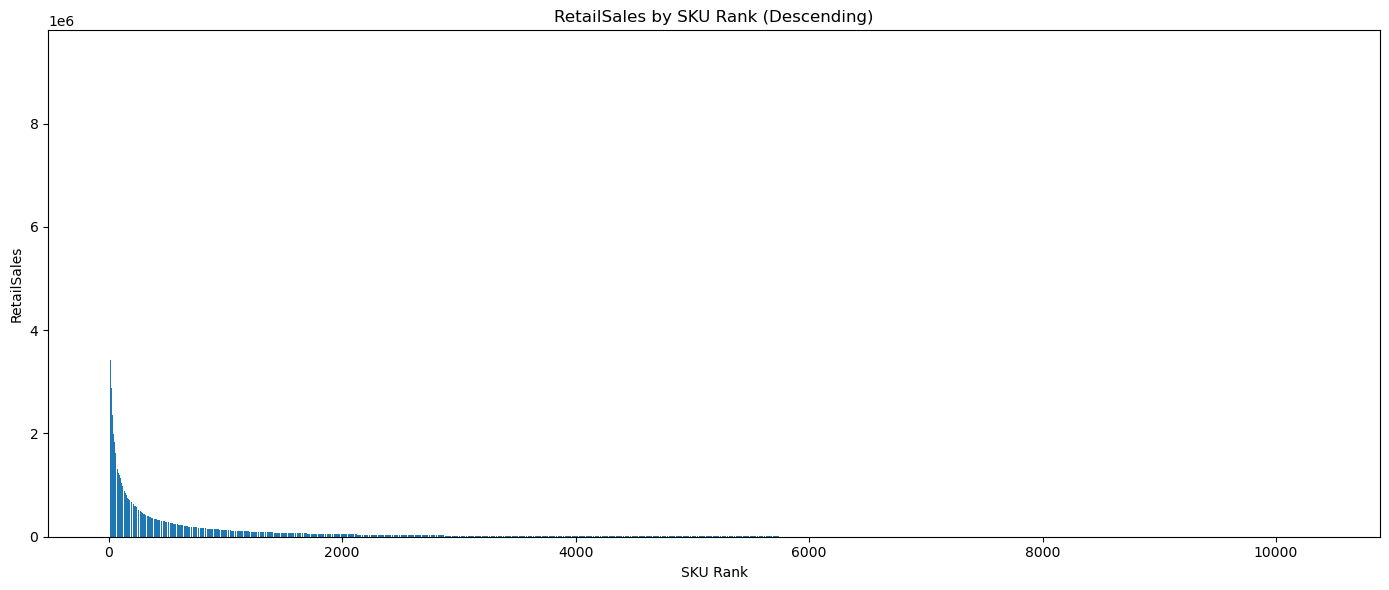

In [93]:
plt.figure(figsize=(14, 6))
plt.bar(np.arange(len(sku_sales)), sku_sales['RetailSales'])
plt.xlabel('SKU Rank')
plt.ylabel('RetailSales')
plt.title('RetailSales by SKU Rank (Descending)')
plt.tight_layout()
plt.show()

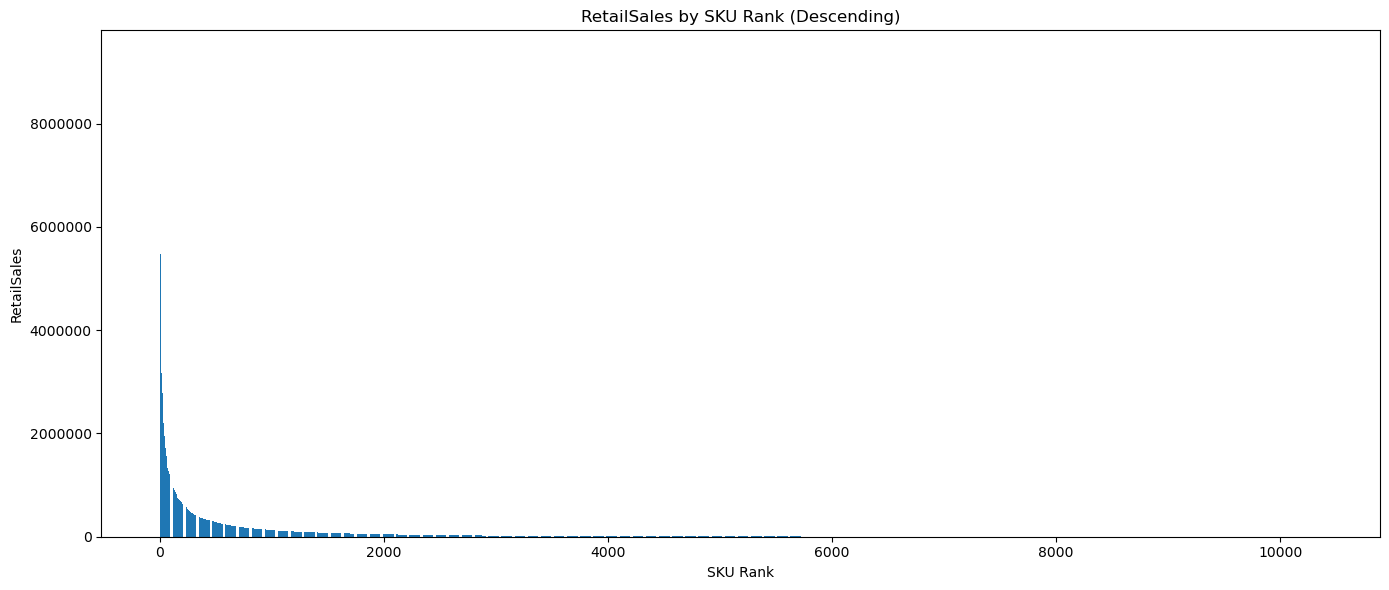

In [97]:
plt.figure(figsize=(14, 6))
plt.bar(np.arange(len(sku_sales)), sku_sales['RetailSales'])
plt.xlabel('SKU Rank')
plt.ylabel('RetailSales')
plt.title('RetailSales by SKU Rank (Descending)')

# Y축을 일반 숫자 표기로!
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter(useOffset=False))
plt.ticklabel_format(style='plain', axis='y')  # Y축 표기 Plain Number

plt.tight_layout()
plt.show()

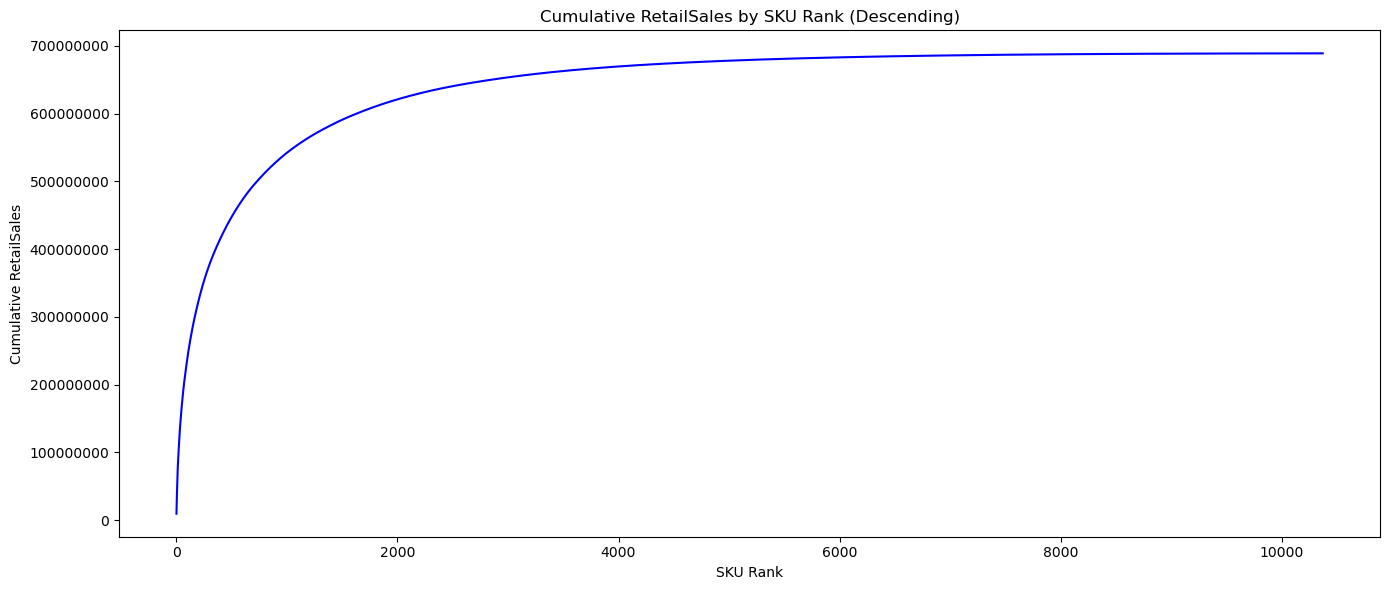

In [101]:
plt.figure(figsize=(14, 6))
plt.plot(np.arange(len(sku_sales)), sku_sales['CumulSales'], color='blue')
plt.xlabel('SKU Rank')
plt.ylabel('Cumulative RetailSales')
plt.title('Cumulative RetailSales by SKU Rank (Descending)')

# Y축 숫자 표기를 일반 표기로(지수 아님)
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter(useOffset=False))
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

In [107]:
total_sales = sku_sales['RetailSales'].sum()
sku_sales['CumulSalesPercent'] = sku_sales['CumulSales'] / total_sales * 100

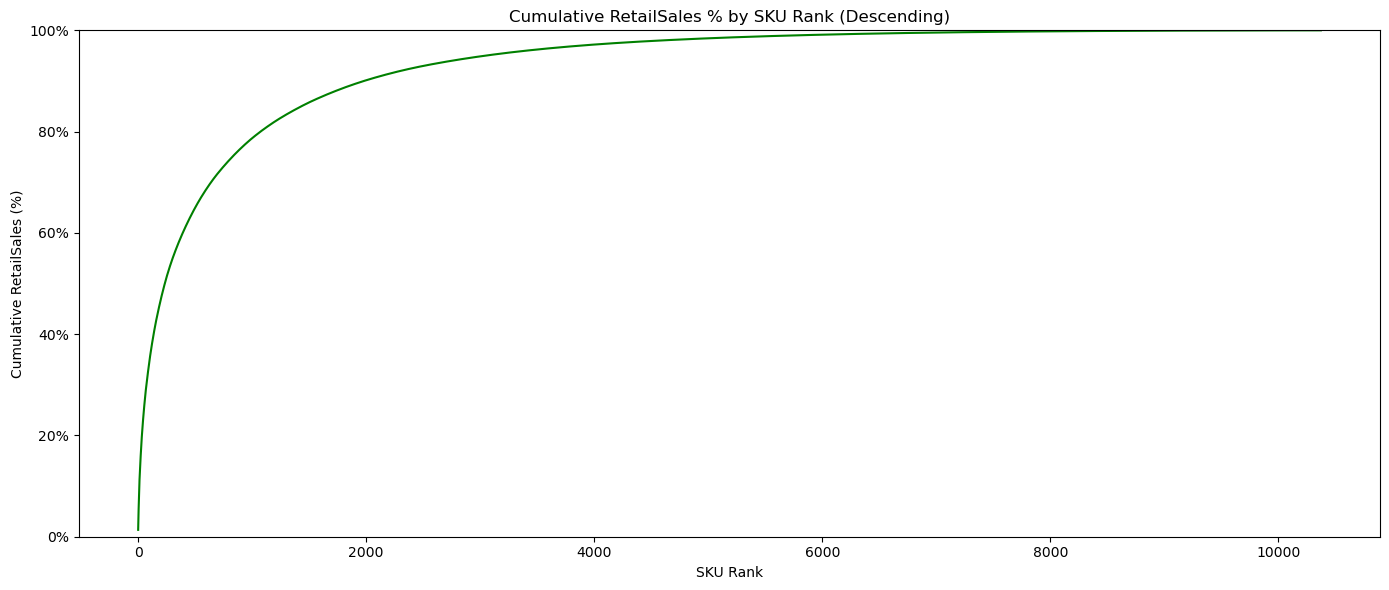

In [109]:
# 누적 매출 % 그래프
plt.figure(figsize=(14, 6))
plt.plot(np.arange(len(sku_sales)), sku_sales['CumulSalesPercent'], color='green')
plt.xlabel('SKU Rank')
plt.ylabel('Cumulative RetailSales (%)')
plt.title('Cumulative RetailSales % by SKU Rank (Descending)')

# Y축을 0~100%로 제한
plt.ylim(0, 100)
plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter())

plt.tight_layout()
plt.show()

In [89]:
# 5. 상위 80%를 차지하는 asin 리스트 추출
asin_top80 = asin_sales[asin_sales['cumrate'] <= 0.8]['asin'].tolist()
print(len(asin_top80))

113


In [91]:
df_top80 = df[df['asin'].isin(asin_top80)]
print(df_top80)

        crawl_date        asin  rating  ratings_total  salesrank1  salesrank2  \
51      2023-08-17  B09XM73Z65     4.5        78306.0      1009.0         2.0   
93      2023-08-17  B095W72PK1     4.5          253.0     52971.0        67.0   
144     2023-08-17  B075GW4GXH     4.6        19051.0      2932.0         3.0   
233     2023-08-17  B07DGHWVN8     4.6         2888.0      8718.0         1.0   
304     2023-08-17  B072HTRVM1     4.5        13738.0     26994.0       152.0   
...            ...         ...     ...            ...         ...         ...   
2636720 2025-06-16  B0CSJX57TM     4.4         5208.0         NaN         NaN   
2636735 2025-06-16  B0CKYYF9SJ     4.2        16430.0         NaN         NaN   
2636741 2025-06-16  B0CKYYHRN6     4.4        78245.0         NaN         NaN   
2636755 2025-06-16  B0CKYSMM1J     4.3        30283.0         NaN         NaN   
2636769 2025-06-16  B06WW43FVV     4.6        17182.0         NaN         NaN   

         salesrank3  bw_pri

In [93]:
df_top80['asin'].nunique()

113

In [109]:
# 해당 컬럼들 중 하나라도 NaN이면 제거
df_cleaned = df_top80.dropna(subset=['rating', 'ratings_total', 'bw_price', 'units', 'gv']).copy()
#df_cleaned = df_top80.rename(columns={'ratings_total': 'ratings_cnt'})
#df_cleaned = df_cleaned.rename(columns={'ratings_total': 'ratings_cnt'}, inplace=True)
print(df_cleaned)

        crawl_date        asin  rating  ratings_total  salesrank1  salesrank2  \
51      2023-08-17  B09XM73Z65     4.5        78306.0      1009.0         2.0   
93      2023-08-17  B095W72PK1     4.5          253.0     52971.0        67.0   
144     2023-08-17  B075GW4GXH     4.6        19051.0      2932.0         3.0   
233     2023-08-17  B07DGHWVN8     4.6         2888.0      8718.0         1.0   
304     2023-08-17  B072HTRVM1     4.5        13738.0     26994.0       152.0   
...            ...         ...     ...            ...         ...         ...   
2635790 2025-06-13  B0CKYYMG6F     4.4        78216.0       399.0         4.0   
2635807 2025-06-13  B0CSJTBM1L     4.4         9849.0       693.0         7.0   
2635842 2025-06-13  B0CSJX57TM     4.4         5200.0      3714.0        18.0   
2635853 2025-06-13  B089ZYJKBK     4.5         2106.0     40615.0       183.0   
2635855 2025-06-13  B0CKYZJY5T     4.2        16413.0      3420.0        16.0   

         salesrank3  bw_pri

In [111]:
df_cleaned.to_csv("0618_amz_pdp_price_sales_gv_top80_data.csv", index=False)